In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [11]:
class Value:
  
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0     #gradient at each node
    self._backward = lambda: None   #function to find chain rule at each node, chaining output gradient to input gradient
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"
  
  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other) #wrap any additional numbers as a Value if it is not of value type already
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
        self.grad += 1.0 * out.grad #for addition in backprop, the gradient just passed down from the previous output for both nodes in the addition
        other.grad += 1.0 * out.grad
    out._backward = _backward
      
    return out

  def __mul__(self, other):
    
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
        self.grad += other.data * out.grad
        other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}') #raise self value to int or float

    def _backward():
        self.grad +=  other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other):     #checking if we can multiply the other way for specific mult cases
      return self * other
      
  def __radd__(self, other):
      return self + other
      
  def __truediv__(self, other):
      return self * other**-1  #implementing division as multiplication with reciprocal

  def __neg__(self): # negate self value
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def tanh(self):
      x = self.data
      t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
      out = Value(t, (self, ), 'tanh')

      def _backward():
          self.grad += (1 - t**2) * out.grad  #think output gradient passed down (multiplied by local function gradient), to get the final self gradient value
         
      out._backward = _backward
      return out

  def exp(self):
      x = self.data
      out = Value(math.exp(x), (self, ), 'exp')
    
      def _backward():
        self.grad += out.data * out.grad #out.data is e^x, which is the derivative of e^x
      out._backward = _backward
    
      return out
      
  def backward(self):

    topo = []    #implementing topological sort going from leaf -> o, chilren first, then parent node
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)   #topoligical order in topo list of each node
    topo

    self.grad = 1.0     #top value gradient is always 1
    for node in reversed(topo):     #in backprop order, we setup gradients 
        node._backward()

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [17]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [19]:
L.grad = 1   #each gradient is calculated through the change in L with respect to the node
d.grad = -2
f.grad = 4
e.grad = 1 * -2
c.grad = 1 * -2
a.grad = -3 * 1 * -2      #chain rule applied for farther down nodes
b.grad = 2 * 1 * -2

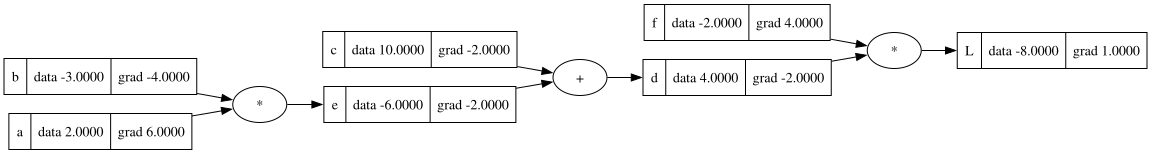

In [21]:
draw_dot(L)

In [23]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b, sum of(values * weights) + bias
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

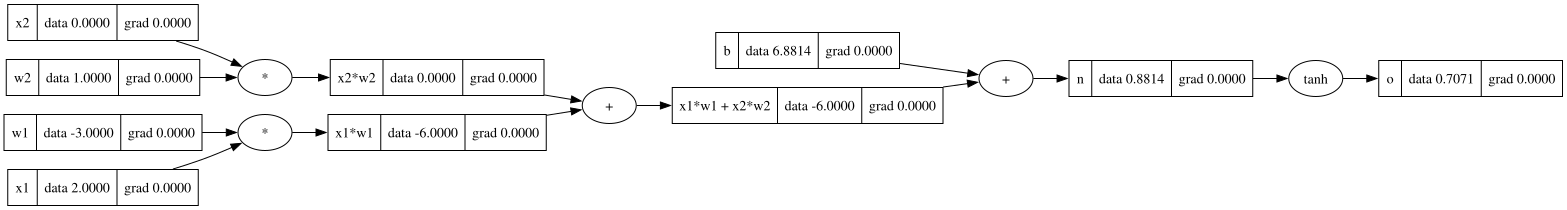

In [25]:
draw_dot(o)

In [27]:
o.backward()

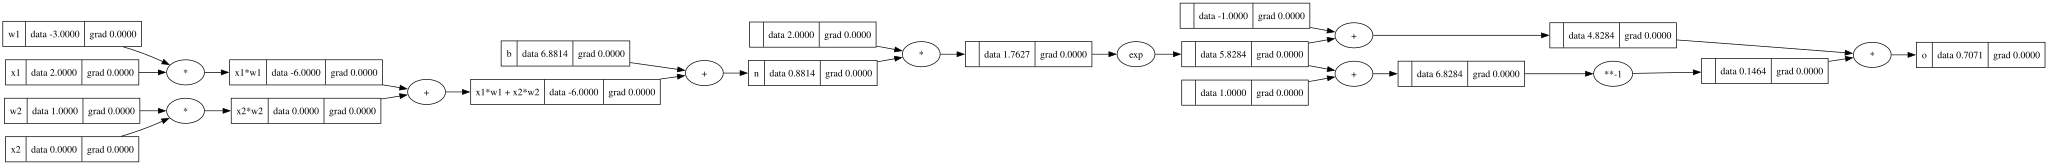

In [29]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b, sum of(values * weights) + bias
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e =(2*n).exp()
o = (e - 1) / (e + 1)

o.label = 'o'
draw_dot(o)

In [31]:
import torch
#micrograd delt with scalars, pytorch is based around tensors (arrays of scalars)
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)   #activation function

print(o.data.item())   #forward pass final value
o.backward()    #backprop calculation

print('---')
print('x2', x2.grad.item())  
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [33]:
#Designing Neural Network class

class Neuron:
    
    def __init__(self, nin): #number of inputs to the neuron
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)] #random weight for each input
        self.b = Value(random.uniform(-1,1)) #random bias value

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)     #combine each incoming data value with a weight and add bias
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    
    def __init__(self, nin, nout):  #number of inputs and output from layer of neurons
        self.neurons = [Neuron(nin) for _ in range(nout)] #initialize number of neurons
  
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]   #activate each neuron
        return outs[0] if len(outs) == 1 else outs
  
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):  #nouts is a list, specifies each layer node size
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] #sets up each layer in pairs
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)            #activate each layer 
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]
    

In [35]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1]) # the layers of the MLP73
n(x)

Value(data=0.7885365501355973)

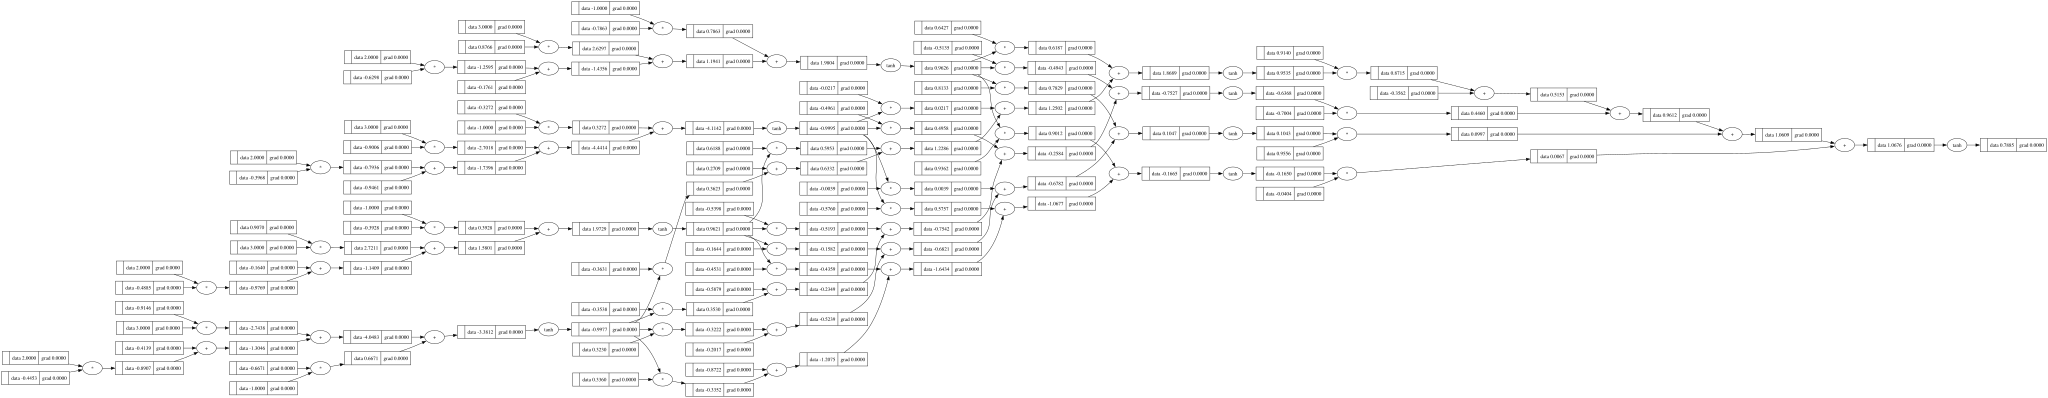

In [39]:
draw_dot(n(x))

In [43]:
#example data set inputs
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [45]:

for k in range(50):    
    #forward pass
    ypred = [n(x) for x in xs]
    # we need a way to measure how close our neural net was to the actual target - loss
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)) #MSE loss summed
    #backprop, gradient calculation
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    #update weights based on the gradient direction
    for p in n.parameters():
        p.data += -0.05 * p.grad #negative learning rate as we want to minimize loss
        
    print(k, loss.data)

0 0.2612120770883659
1 0.18359531036279436
2 0.1393412844124341
3 0.11086341640848213
4 0.0913349229514093
5 0.07725837499547214
6 0.06670401207108996
7 0.05853670468152931
8 0.05205193855431196
9 0.0467923845810761
10 0.042449739386640845
11 0.03880938574915056
12 0.035717756554714736
13 0.03306232222356594
14 0.03075889465832362
15 0.028743329223213397
16 0.026965956761329977
17 0.025387759241769593
18 0.023977687688759516
19 0.022710745675296955
20 0.02156659653627087
21 0.02052853556916731
22 0.019582720928539354
23 0.018717590721546953
24 0.017923416030385407
25 0.01719195445666165
26 0.016516178899177506
27 0.015890063264886796
28 0.01530841170868951
29 0.014766721472813125
30 0.014261071893287187
31 0.013788033955311384
32 0.013344596111724331
33 0.012928103067050983
34 0.01253620496947336
35 0.012166815011844134
36 0.011818073868357653
37 0.011488319720033523
38 0.011176062874611965
39 0.010879964182987313
40 0.010598816608310283
41 0.010331529425335526
42 0.010077114623925954


In [47]:
ypred

[Value(data=0.9647298664112578),
 Value(data=-0.992525828584233),
 Value(data=-0.9436912794120014),
 Value(data=0.9358133604932635)]

In [49]:
# we can see how through the training process (forward pass, taking gradients w.r.t loss, 
# adjusting weights in the direction to minimize loss, and repeating this process) the neural network
# gets closer and closer to our desired target outputs [1, -1, -1, 1]
